In [1]:
import os, sys, pickle
from importlib import reload
%pylab inline
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec
plt.style.use('default')
plt.rcParams['figure.figsize'] = (8, 2.5)
from label_axes.label_axes import label_axes
def inspect(obj):
    return [f for f in dir(obj) if not f.startswith("_")]

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
from glom_io_transform import paths

proj_path='/camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform'
fits_root='/camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/model_fitting'
data_root='/camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/data'


# Figure: Explain Models

In [47]:
from glom_io_transform.analysis.compute import explain_models as compute_explain_models
reload(compute_explain_models)
explain_models_data = compute_explain_models.Data().compute(seeds=np.arange(50))

COMPUTING explain_models.Data.
Loaded split models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/model_fitting/fits/loss=cov/matched=False/center=True/standardization=separate/normalization=odour_std/sampler=trials/mode=random/n_od_train=max/loaded_models.p.
Free connectivity theory: seeds=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49], selection_metric='ratio', ref_seed=0, ref_train=0
Processing seed 0 (1/50)
Computing props for seed=np.int64(0) with best λ=10
Processing seed 1 (2/50)
Computing props for seed=np.int64(1) with best λ=10
Processing seed 2 (3/50)
Computing props for seed=np.int64(2) with best λ=10
Processing seed 3 (4/50)
Computing props for seed=np.int64(3) with best λ=31.6
Processing seed 4 (5/50)
Computing props for seed=np.int64(4) with best λ=31.6
Processing seed 5 (6/50)
Computing props for seed=np.int64(5) with best λ

PLOTTING FIGURE ExplainModels
PLOTTING PANELS DiagPhase
PLOTTING PANELS DiagApprox
PLOTTING PANELS FreeConn
PLOTTING PANELS FreeConnModes
PLOTTING PANELS FreeConnModesHist
    #  owner           role           size       x      y  text
    0  phase/inset[0]  xlabel         12.0   0.303  0.563  'Output'
    1  phase/inset[1]  xlabel         12.0   0.071  0.596  'Output'
    2  phase/inset[2]  xlabel         12.0   0.272  0.596  'Output'
    3  approx_W        xlabel         12.0   0.463  0.537  'Output'
    4  approx_J        xlabel         12.0   0.685  0.537  'Output'
    5  approx_U        xlabel         12.0   0.907  0.537  'Output'
    6  conn            ylabel         12.0   0.041  0.287  'Output Glomerulus'
    7  conn_           ylabel         12.0   0.268  0.287  'Output Glomerulus'
Saved figure to /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/figs/fig_explain_models.pdf


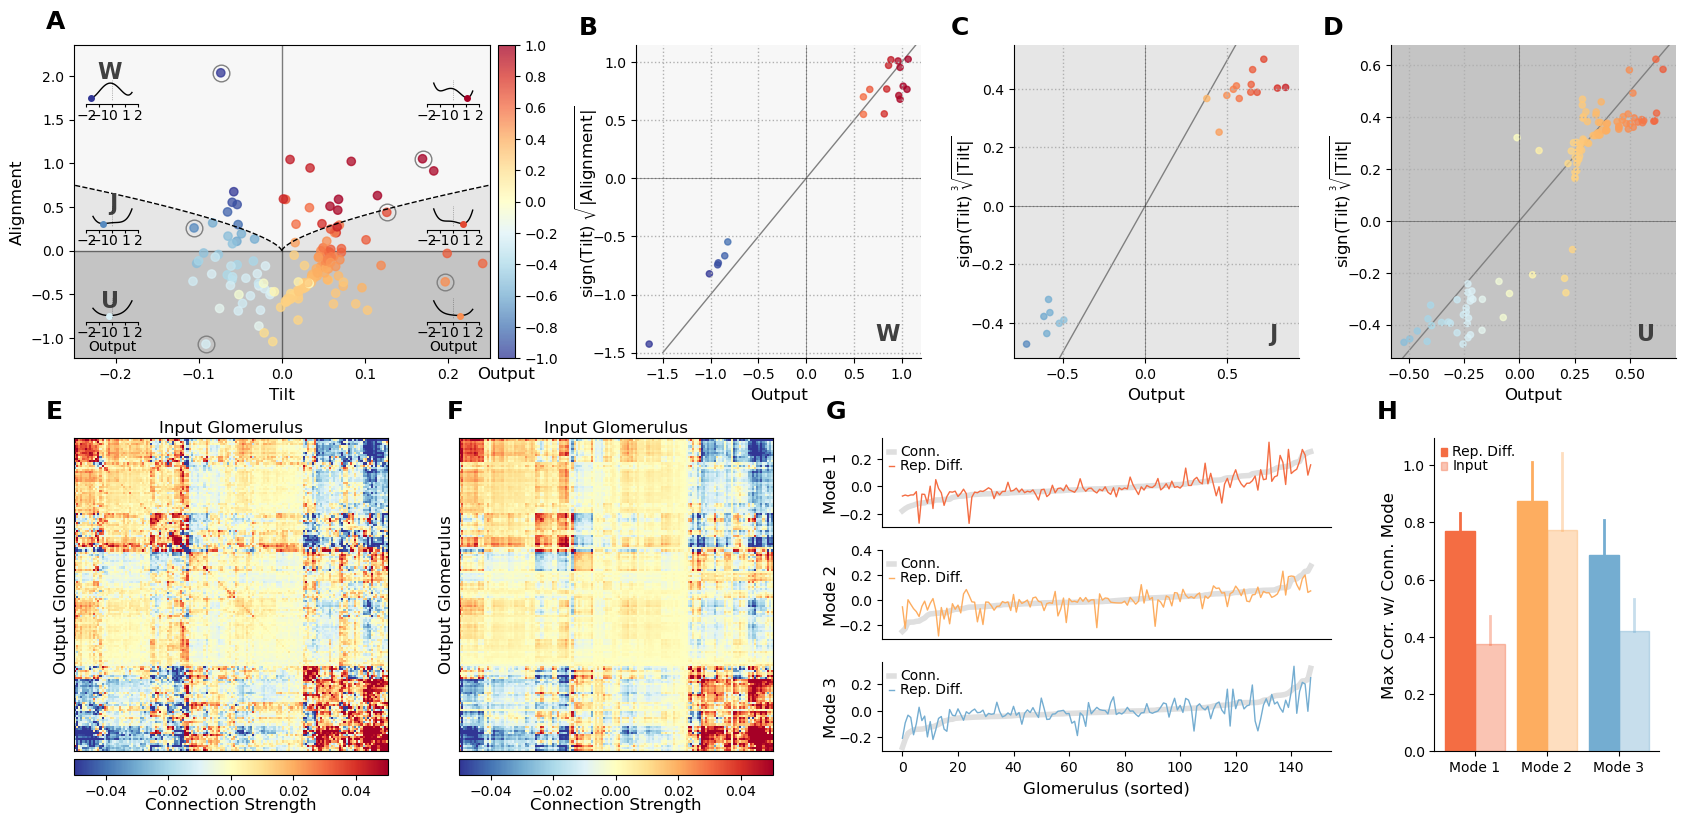

In [50]:
from glom_io_transform.analysis.figures import figures as fig_figures; reload(fig_figures)
from glom_io_transform.analysis.figures import diag as fig_diag; reload(fig_diag)
from glom_io_transform.analysis.figures import free as fig_free; reload(fig_free)
from glom_io_transform.analysis.figures import explain_models as fig_explain_models
reload(fig_explain_models)
from glom_io_transform.analysis.figures.figures import reduce_vertical_gaps, reduce_horizontal_gaps
fig = figure(figsize=(17, 8)); #title("HellO")
ax = fig_explain_models.Main.plot(explain_models_data, phase_width=3.5, approx_width=2.4, hist_width=2)
tight_layout()
ax_modes = ax["modes"]
#ax_hist = ax["hist"]
#reduce_vertical_gaps(ax_modes, 0.1)
fig_figures.set_label_sizes(fig, 12)
fig_figures.set_tick_sizes(fig, 10)
fig_figures.set_label_pads(fig, -5, axes=[ax["approx_J"], ax["approx_U"], ax["approx_W"]], which="y")
fig_figures.set_legend_sizes(fig, 10)
bottom_row = [ax["conn"], ax["conn_"], ax["modes"], ax["hist"]]
fig_figures.pack_horizontally(bottom_row, gap=0.03, grow=[2,3], use_drawn=True)
#reduce_horizontal_gaps([ax[f"approx_{ch}"] for ch in "WJU"], 0.00)
top_row = [ax["phase"], ax["approx_W"], ax["approx_J"], ax["approx_U"]]
reduce_horizontal_gaps(top_row,0.03)
fig_figures.shift_axes(bottom_row, dx=-0.01)
#fig_figures.scale_axes(ax["hist"], fx=0.8, anchor_x = "left")
hits = fig_figures.find_text(fig, "Output", names=ax)
hits[1]["artist"].set_fontsize(10)
hits[2]["artist"].set_fontsize(10)
hits[0]["artist"].set_fontsize(12)
order = ["phase", "approx_W", "approx_J", "approx_U", "conn", "conn_", "modes", "hist"]
label_axes([ax[k] if k != "modes" else ax[k][0] for k in order], "ABCDEFGH", fontsize=18, fontweight="bold", 
           dy=[-0.005]*4 + [0]*4,
            align_x=[[0,4]],
            align_y=[[4,5,6,7]]
)

fig_figures.crop_to_content(fig, margin=0.05)
fig_file = f"{paths.proj_path}/figs/fig_explain_models.pdf"
savefig(fig_file, bbox_inches="tight", dpi=600)
print(f"Saved figure to {fig_file}")

# Figure: Show Models

In [3]:
from glom_io_transform.analysis.compute import generalization as compute_generalization; reload(compute_generalization)
from glom_io_transform.analysis.compute import show_models as compute_show_models; reload(compute_show_models)
show_models_data = compute_show_models.Data().compute(compute_df = False)

Loading  /nemo/lab/schaefera/working/tootoos/git/glom-io-transform-release/glom_io_transform/analysis/compute/compute.py
COMPUTING show_models.Data.
Loaded generalization results from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/model_fitting/generalization_results/generalization_results.pkl.
Loaded split models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/model_fitting/fits/loss=cov/matched=False/center=True/standardization=separate/normalization=odour_std/sampler=trials/mode=random/n_od_train=max/loaded_models.p.


PLOTTING FIGURE ShowModels
PLOTTING PANELS Schem
PLOTTING PANELS Schem

  Correlation Mismatch — trials/random   (n = 50 units, two-sided Wilcoxon, holm correction over 15 pairs)
    Output < Input      median -0.2385 IQR [-0.2431, -0.2339]   p =  1.8e-15  p_holm =  2.7e-14   ***
    Diag < Input        median -0.1604 IQR [-0.1656, -0.1506]   p =  1.8e-15  p_holm =  2.7e-14   ***
    DiagInh < Input     median -0.1515 IQR [-0.1577, -0.1430]   p =  1.8e-15  p_holm =  2.7e-14   ***
    Free < Input        median -0.1483 IQR [-0.1527, -0.1402]   p =  1.8e-15  p_holm =  2.7e-14   ***
    FreeLat < Input     median -0.1473 IQR [-0.1536, -0.1395]   p =  1.8e-15  p_holm =  2.7e-14   ***
    Output < Diag       median -0.0780 IQR [-0.0834, -0.0746]   p =  1.8e-15  p_holm =  2.7e-14   ***
    Output < DiagInh    median -0.0869 IQR [-0.0913, -0.0839]   p =  1.8e-15  p_holm =  2.7e-14   ***
    Output < Free       median -0.0895 IQR [-0.0947, -0.0841]   p =  1.8e-15  p_holm =  2.7e-14   ***
    O

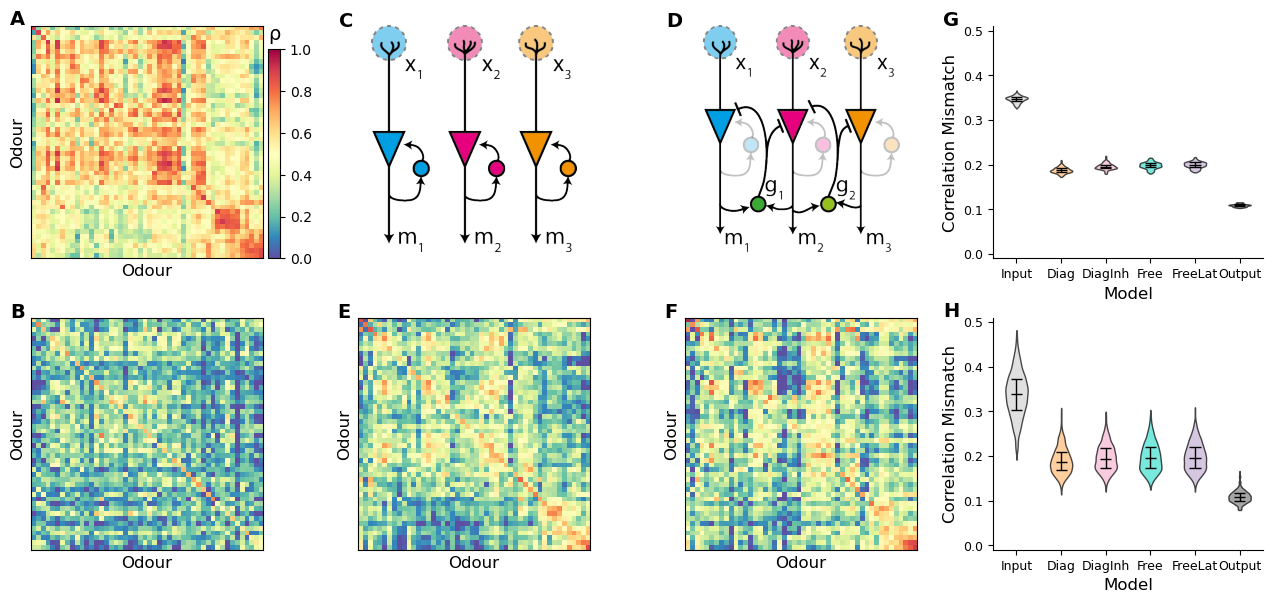

In [6]:
from glom_io_transform.data import odours; reload(odours)
from glom_io_transform.analysis.figures import violin_plots; reload(violin_plots)
from glom_io_transform.analysis.figures import show_models as fig_show_models; reload(fig_show_models)
from glom_io_transform import paths
fig = figure(figsize=(13, 6)); 
ax = fig_show_models.Main.plot(show_models_data)
tight_layout(w_pad=0.5)
order = ["rep_in", "rep_star", "circ_diag", "circ_free", "rep_diag", "rep_free", "gen_trials", "gen_outclass"]
label_axes([ax[k] for k in order], "ABCDEFGH", fontsize=14, fontweight="bold")
fig_file = f"{paths.proj_path}/figs/fig_show_models.pdf"
savefig(fig_file, bbox_inches="tight", dpi=600)
print(f"Saved figure to {fig_file}")

# Generalization Supplementaries

## Compute Generalization
This is stale, use `generalization.py' now.

In [3]:
from glom_io_transform.analysis import compute; reload(compute)
from glom_io_transform.model_fitting import results, split; reload(results); reload(split)
from glom_io_transform.analysis.compute import generalization as compute_generalization
reload(compute_generalization)

loss       = "cov"
matched    = False
n_od_train = "max"
alpha      = None

if n_od_train == "max":
    which_models = ["Diag", "DiagOnlyInh", "Free", "FreeLat"]
else:
    if alpha is None:
        which_models = ["Diag", "Free"]
        if loss == "resp":
            which_models += ["FreePSD", "FreeSym", "FreeRot", "FreeOrth"]
    else:
        assert loss == "resp", "Loss must be 'resp' when alpha is not None"
        which_models = ["Free", "FreeSym"]

generalization_data = compute_generalization.Data().compute(compute_df=False, 
                                                            loss=loss, 
                                                            matched=matched,
                                                            which_models=which_models,
                                                            splits=[("trials", "random", n_od_train),
                                                                    #("odours", "random", "max")
                                                                    ],
                                                            check_staleness=True,
                                                            alpha=alpha

                                                            )

Loading  /nemo/lab/schaefera/working/tootoos/git/glom-io-transform-release/glom_io_transform/analysis/compute/compute.py
COMPUTING generalization.Data.
Loaded generalization results from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/model_fitting/generalization_results/generalization_results.pkl.


## Plot Generalization Violinplots

PLOTTING FIGURE Generalization (prefix='cov')
PLOTTING FIGURE Generalization (prefix='corr')
PLOTTING FIGURE Generalization (prefix='corr_en')
Saved figure to /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/figs/supp__generalization_results__splits.pdf
PLOTTING FIGURE Generalization (prefix='cov')
PLOTTING FIGURE Generalization (prefix='corr')
PLOTTING FIGURE Generalization (prefix='corr_en')
Saved figure to /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/figs/supp__generalization_results__outclass.pdf


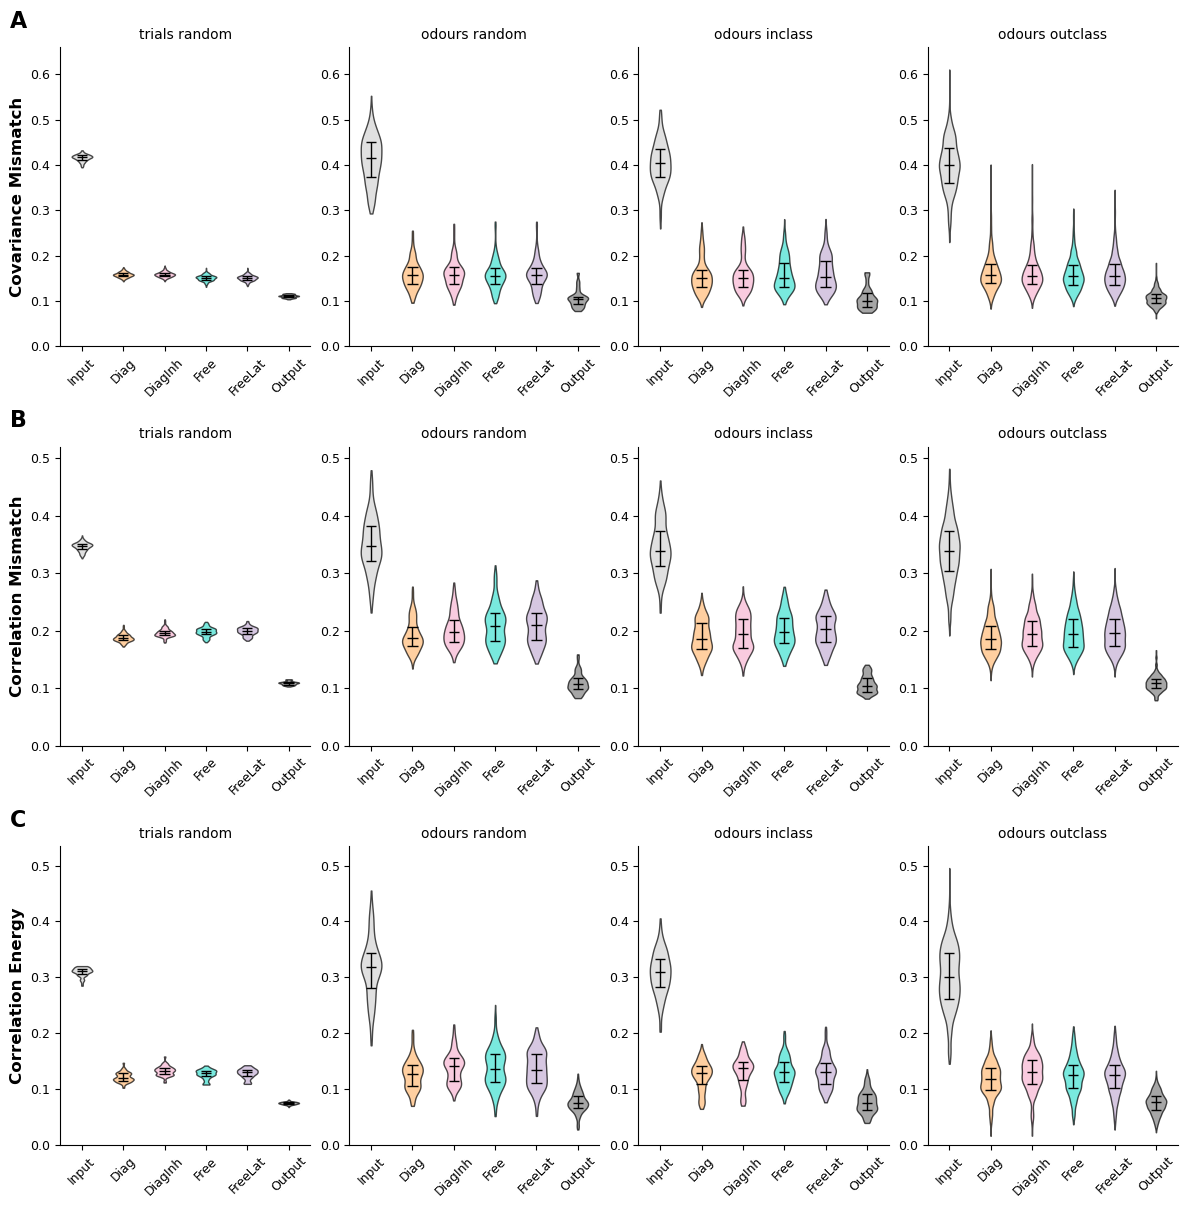

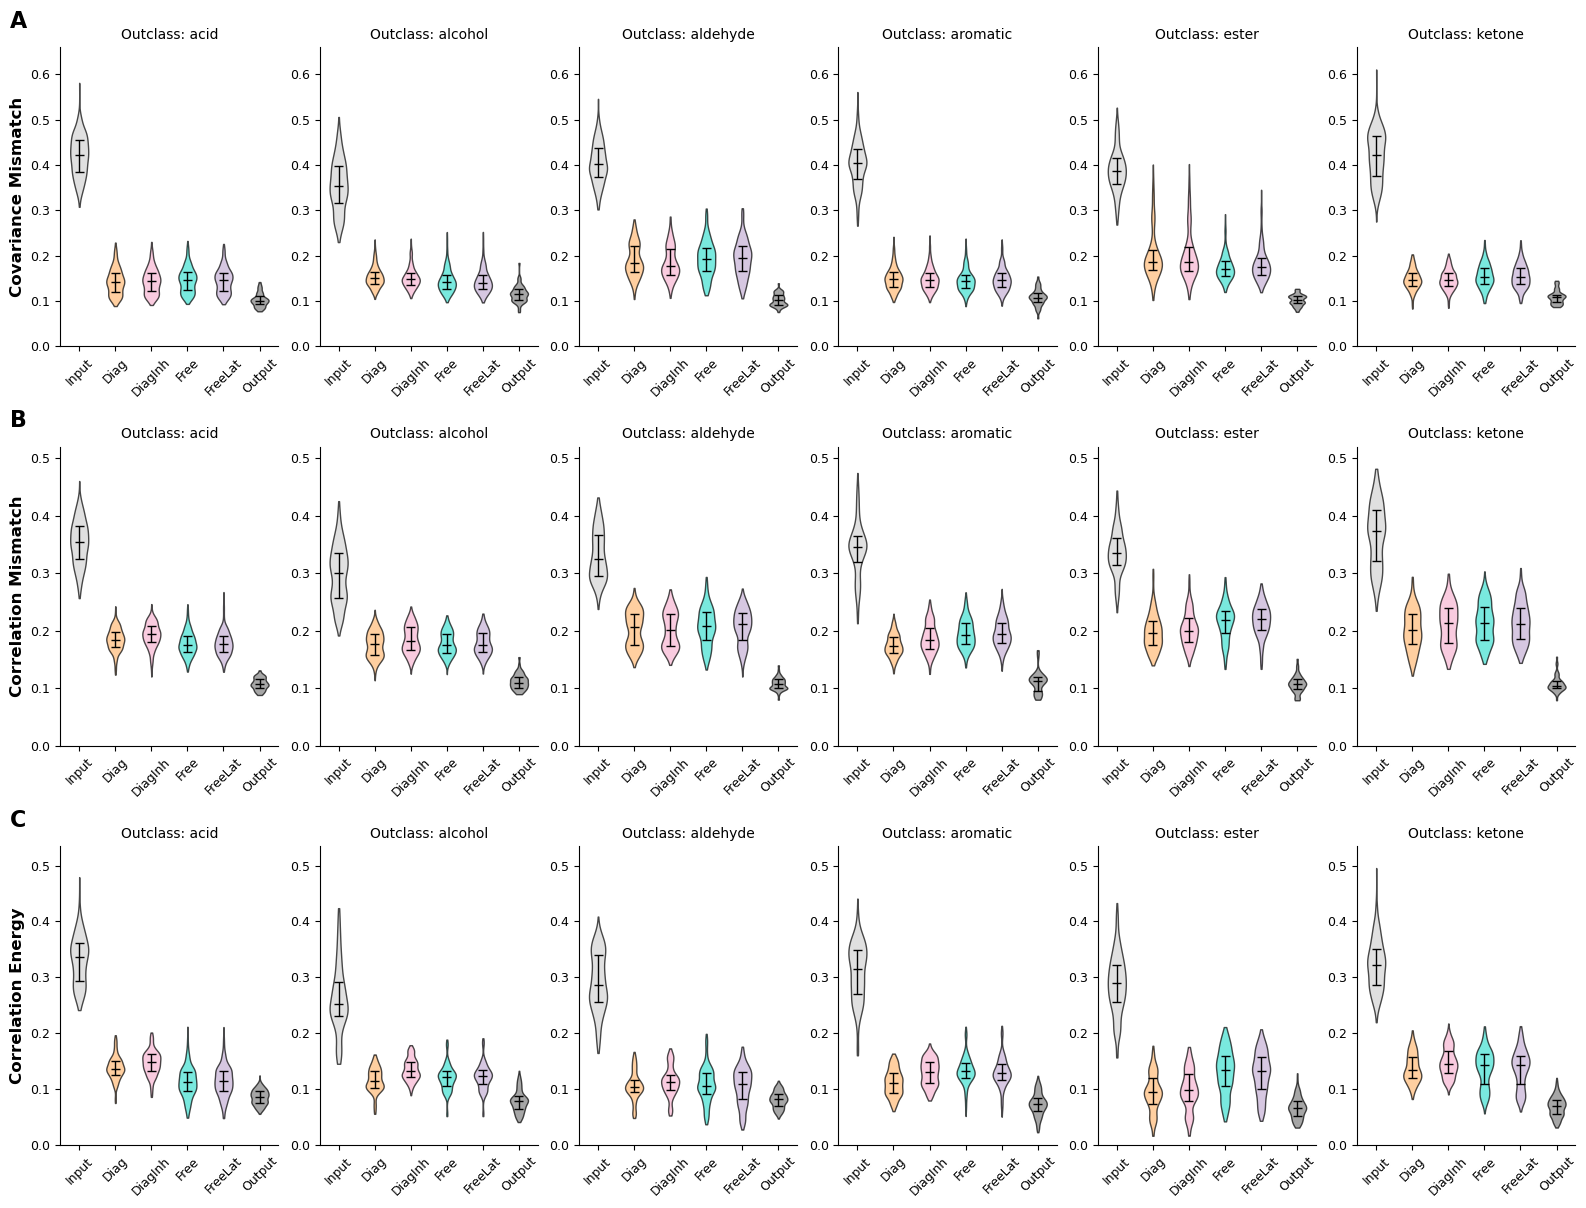

In [4]:
from glom_io_transform.analysis.figures import generalization as fig_generalization; reload(fig_generalization)
figname_stem = os.path.basename(generalization_data.cache_file).replace(".pkl", "")

for plot_mode in ["splits", "outclass"]:
    fig = plt.figure(figsize=(12 if plot_mode == "splits" else 16, 12))
    n_col = 4 if plot_mode == "splits" else 6
    gs = GridSpec(3, n_col)
    ax_lab = []
    for i, metric in enumerate(["cov", "corr", "corr_en"]):
        ax_list = [plt.subplot(gs[i, j]) for j in range(n_col)]
        axes = fig_generalization.Supp.plot(generalization_data, 
                                            prefix=metric, figsize=None, ax_list=ax_list,
                                            plot_splits = (plot_mode == "splits"),
                                            plot_outclass = (plot_mode == "outclass"))
        # Set the x-tick label rotation to 45 degrees for all axes
        for ax in axes.values():
            plt.sca(ax)
            plt.xticks(rotation=45)
        # Set the ylabel fontsize and weight for the first axis
        ax_list[0].set_ylabel(ax_list[0].get_ylabel(), fontsize=12, fontweight='bold', fontfamily='sans-serif')
        ax_lab.append(ax_list[0])
    tight_layout(w_pad=0.5, h_pad=2)
    label_axes(ax_lab, "ABC", fontsize=16, fontweight="bold")
    fig_file=f"{paths.proj_path}/figs/supp__{figname_stem}__{plot_mode}.pdf"
    savefig(fig_file, bbox_inches="tight", dpi=600)
    print(f"Saved figure to {fig_file}")


# Matched ROIs Analysis

In [131]:
from glom_io_transform import logs; logs.quiet()
from glom_io_transform.model_fitting import driver; reload(driver)
from glom_io_transform.analysis import compute; reload(compute)
from glom_io_transform.analysis.compute import matched_rois as compute_matched_rois; reload(compute_matched_rois)
from glom_io_transform.analysis.figures import figures as fig_figures; reload(fig_figures)
from glom_io_transform.analysis.figures import matched_rois as fig_matched_rois; reload(fig_matched_rois)

<module 'glom_io_transform.analysis.figures.matched_rois' from '/nemo/lab/schaefera/working/tootoos/git/glom-io-transform-release/glom_io_transform/analysis/figures/matched_rois.py'>

## Compute Matched ROI Data

In [147]:
main_fig = "18_rand_0"

n_od_train = "18_rand_0" #"18_var_output"
fig_prefix = f"fig" if n_od_train == main_fig else f"supp__{n_od_train}"

In [148]:
# Add colorbar for the heatmaps
matched_rois_data = compute_matched_rois.Data().compute(n_od_train=n_od_train)

COMPUTING matched_rois.Data.
Loaded generalization results from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/model_fitting/generalization_results/generalization_results_matched_n_od_train=18_rand_0.pkl.
Loaded generalization results from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/model_fitting/generalization_results/generalization_results_loss=resp_matched_n_od_train=18_rand_0.pkl.
Unique models in gen_df: ['Diag_cov' 'Free_cov' 'Diag_resp' 'Free_resp' 'FreePSD_resp'
 'FreeSym_resp' 'FreeRot_resp' 'FreeOrth_resp']


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:30<00:00, 16.16it/s]


Loaded generalization results from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/model_fitting/generalization_results/generalization_results_loss=resp_matched_alpha=0.0_n_od_train=18_rand_0.pkl.


alpha=0.0: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:06<00:00, 77.28it/s]


Loaded generalization results from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/model_fitting/generalization_results/generalization_results_loss=resp_matched_alpha=0.2_n_od_train=18_rand_0.pkl.


...

Loaded generalization results from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/model_fitting/generalization_results/generalization_results_loss=resp_matched_alpha=0.8_n_od_train=18_rand_0.pkl.


alpha=0.8: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:06<00:00, 76.10it/s]


Loaded generalization results from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/model_fitting/generalization_results/generalization_results_loss=resp_matched_alpha=1.0_n_od_train=18_rand_0.pkl.


alpha=1.0: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:06<00:00, 75.81it/s]


  refitting Diag at loss=resp ...
Regularizing z**1 - 1
bounds (-inf, inf)
Running minimization with 22 initial conditions.
Started at: 2026-09-01 11:48:46
RESP_LOSS at regularization target: 8.05799868e-02
Running minimization with initial condition 1/22.
RUNNING MINIMIZATION using method='L-BFGS-B'.
Started at: 2026-09-01 11:48:46
Gradient check passed with error 8.7089513864145e-18
RESP_LOSS at initial guess: 0.2585982349390415
[   1] f = 1.91197827e-01 RESP_LOSS = 1.91197755e-01 REG = 7.19706106e-08 |g|inf = 4.600e-02
[   2] f = 1.04463998e-01 RESP_LOSS = 1.04463940e-01 REG = 5.78776831e-08 |g|inf = 1.188e-02
[   3] f = 7.95052365e-02 RESP_LOSS = 7.95051867e-02 REG = 4.98677551e-08 |g|inf = 1.609e-02
[   4] f = 4.08650994e-02 RESP_LOSS = 4.08650663e-02 REG = 3.30570372e-08 |g|inf = 6.201e-03
[   5] f = 3.28441455e-02 RESP_LOSS = 3.28441188e-02 REG = 2.67896486e-08 |g|inf = 2.251e-03
[   6] f = 2.87549809e-02 RESP_LOSS = 2.87549594e-02 REG = 2.15423926e-08 |g|inf = 8.435e-04
[   7] 

In [149]:
# Save the matched_rois_data to a pickle file
matched_rois_data_file = f"{paths.proj_path}/out/matched_rois_data.p"
with open(matched_rois_data_file, "wb") as f:
    pickle.dump(matched_rois_data, f)

## Plot Main Panel

PLOTTING FIGURE matched_rois
PLOTTING PANELS Schem

  R² ladder — trials/random   (n = 50 seeds, Wilcoxon signed rank)

    one-sided, each rung against zero   (Holm over the 9 rungs)
      Free cov > 0      median -1.22 [-1.273, -1.091]  p = 1         p_holm = 1         n.s.
      Free cov+m > 0    median -0.757 [-0.8156, -0.6504]  p = 1         p_holm = 1         n.s.
      Stretch > 0       median -0.02756 [-0.07095, +0.02363]  p = 0.998     p_holm = 1         n.s.
      Rot > 0           median +0.03743 [+0.01493, +0.07519]  p = 5.82e-06  p_holm = 2.91e-05  ***
      Orth > 0          median +0.0377 [+0.01493, +0.07491]  p = 1.28e-05  p_holm = 5.11e-05  ***
      White > 0         median +0.0454 [+0.02595, +0.08013]  p = 3.86e-07  p_holm = 2.32e-06  ***
      Diag resp > 0     median +0.09502 [+0.06879, +0.1337]  p = 2.9e-09   p_holm = 2.03e-08  ***
      Free resp > 0     median +0.2302 [+0.1933, +0.2791]  p = 4.44e-15  p_holm = 3.55e-14  ***
      Sym > 0           median +0.2395

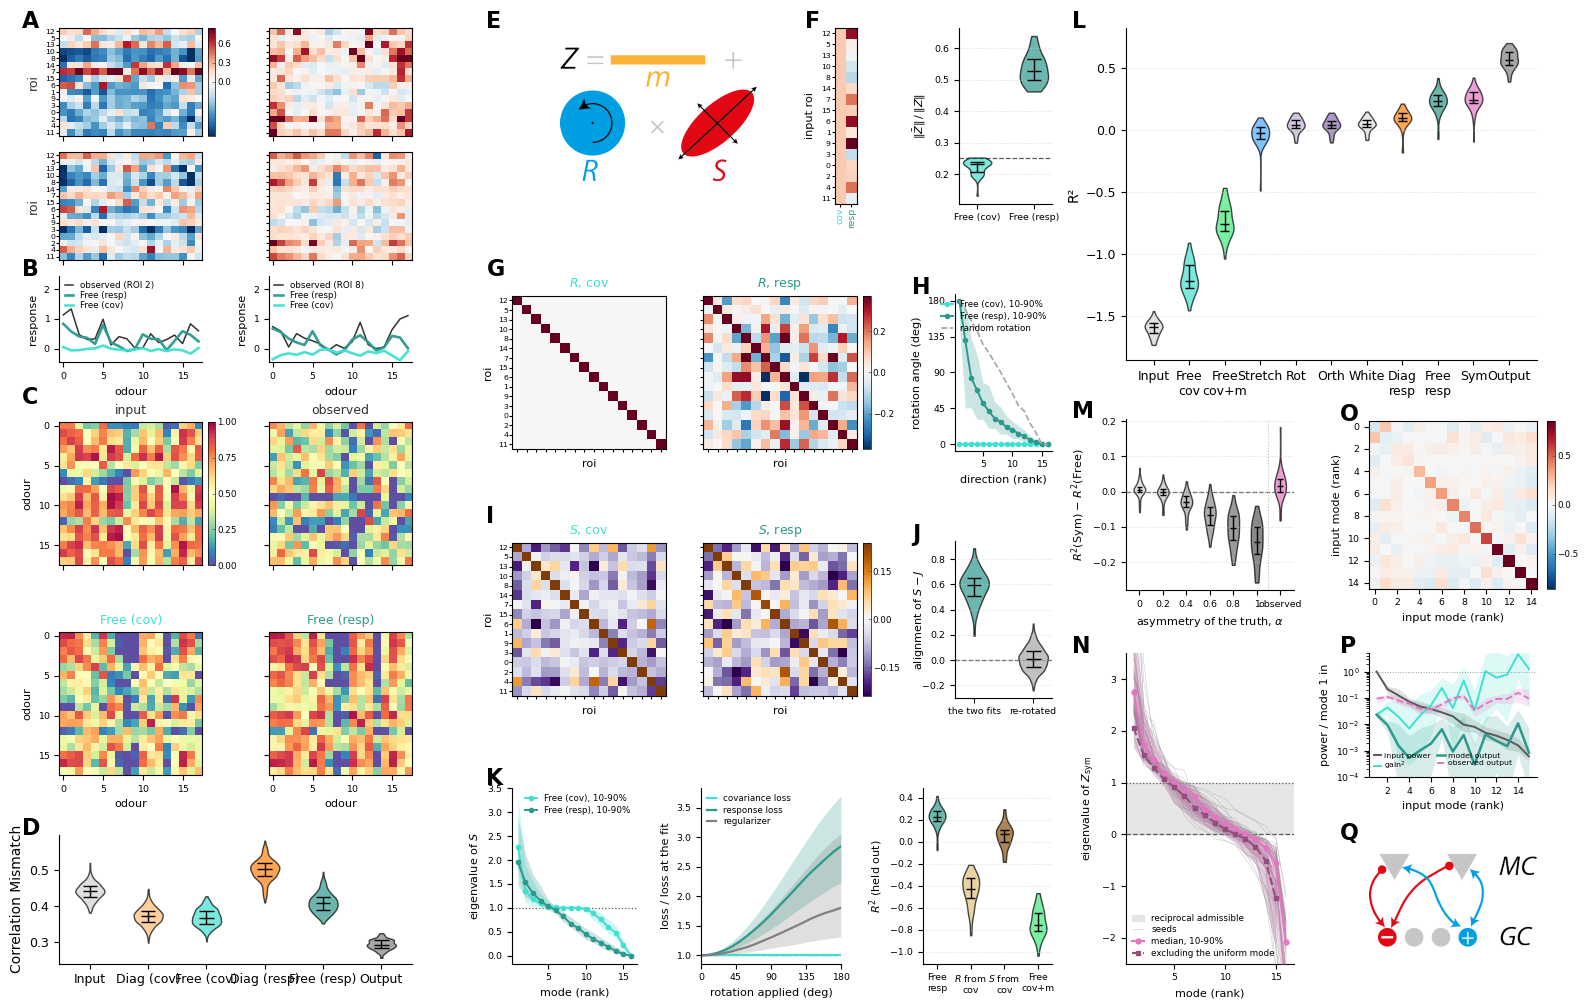

In [151]:
from glom_io_transform.analysis.compute import generalization as compute_generalization; reload(compute_generalization)
from glom_io_transform.model_fitting import proc_fit_models as proc_fit_models; reload(proc_fit_models)
from glom_io_transform.analysis.figures import figures as fig_figures; reload(fig_figures)
from glom_io_transform.analysis.figures import violin_plots as fig_violin_plots; reload(fig_violin_plots)
from glom_io_transform.analysis.figures import matched_rois as fig_matched_rois; reload(fig_matched_rois)

figure(figsize=(16, 10))
axes = fig_matched_rois.Main.plot(matched_rois_data, quantiles=(10,90));
axes["z_spectrum"].set_ylim(-2.5,3.5)
axes["whitening"].set_ylim(1e-4,5)
tight_layout(w_pad=0.5, h_pad=0.5)

labels = ["input_heatmap",
          "roi_1",
          "corr_input",
          "violin",
          "conn_schematic",
          "baseline_strip",
          "R_cov",
          "rot_angles",
          "S_cov",
          "stretch_align",
          "stretch_spectra",
          "r2_heldout",
          "surrogate_alpha",
          "z_spectrum",
          "mode_conn",
          "whitening",
          "schematic"
]
alphabet = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
str2inds= lambda s: [alphabet.index(c) for c in s]
label_axes([axes[k] for k in labels], alphabet, fontsize=16, fontweight="bold", 
           align_x= [
               str2inds("ABCD"),
               str2inds("HJ"),
               str2inds("EGIK"),
               str2inds("LMN"),
               str2inds("OPQ"),
            ]
)
fig_file = f"{paths.proj_path}/figs/{fig_prefix}_matched_rois.pdf"
savefig(fig_file, bbox_inches="tight", dpi=600)
print(f"Saved figure to {fig_file}")

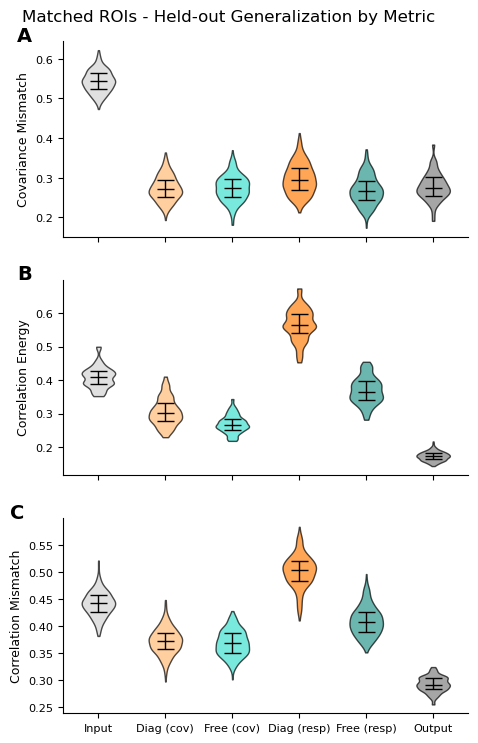

In [63]:
fig = figure(figsize=(5, 8))
axes = fig_matched_rois.Supp.plot_mismatch(matched_rois_data, fig = fig)
fig.suptitle("Matched ROIs - Held-out Generalization by Metric")
label_axes([axes[k] for k in axes], "ABC", fontsize=14, fontweight="bold")
savefig(f"{paths.proj_path}/figs/supp__matched_rois__mismatch.pdf", bbox_inches="tight", dpi=600)

## Plot Supplementary Panel

PLOTTING FIGURE matched_rois (metric='resp')
  sign-aligned rois (covariance fits cannot see channel sign): Diag 8/16, Free 8/16
PLOTTING FIGURE matched_rois (metric='cov')
PLOTTING FIGURE matched_rois (metric='corr')


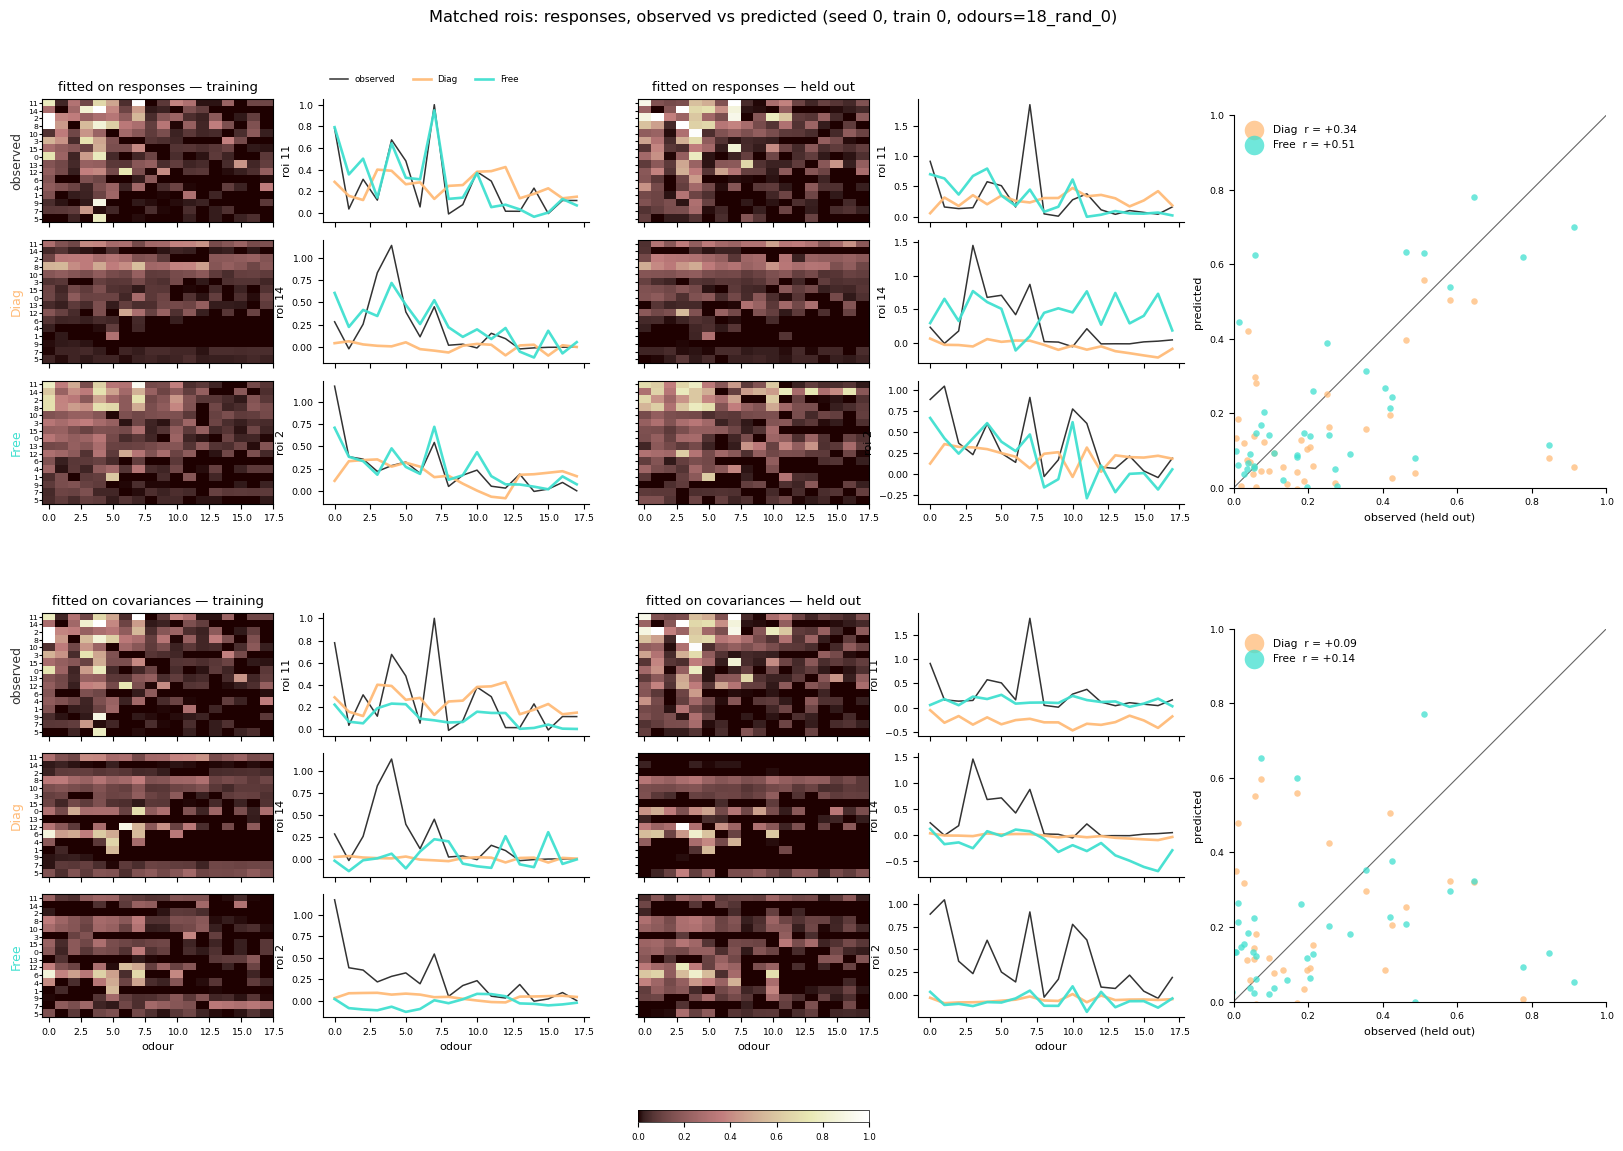

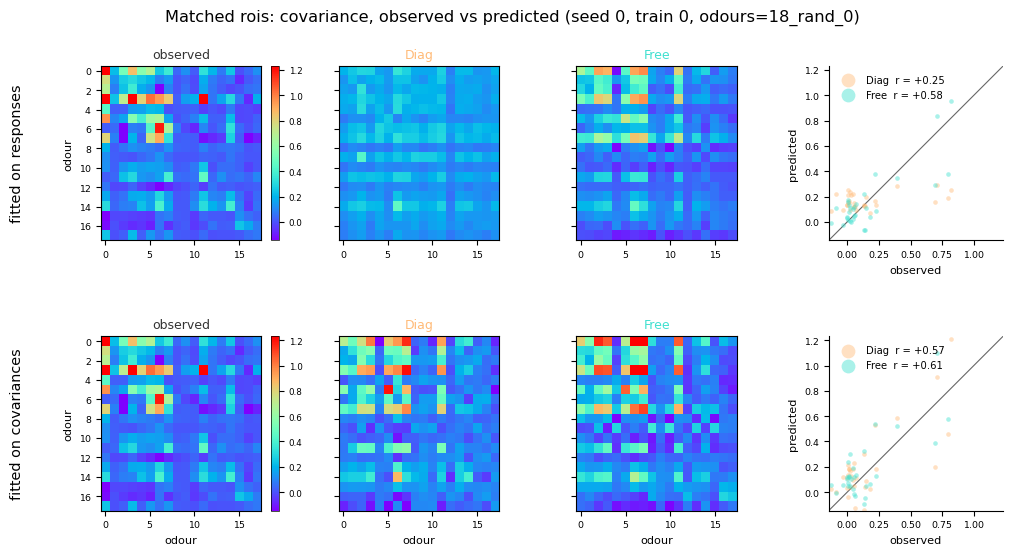

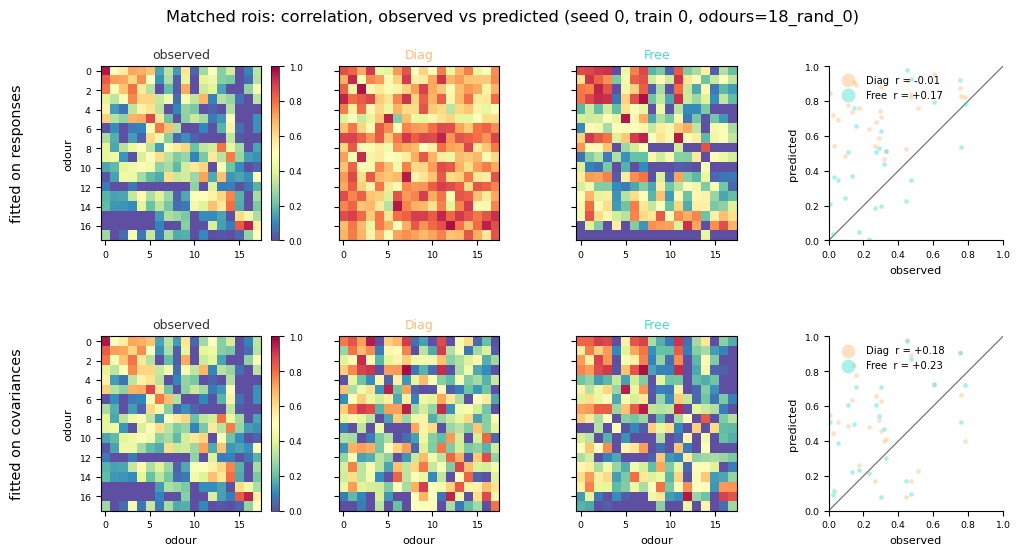

In [ ]:

for metric in ["resp", "cov", "corr"]:
    fig_matched_rois.Supp.plot(matched_rois_data, metric=metric)